In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [33]:
# -------------------------
# Base Generators (Single Channel)
# -------------------------

def generate_trend_channel(T):
    t = np.linspace(0, 1, T)
    a = np.random.uniform(1.0, 3.0)
    b = np.random.uniform(-1.0, 1.0)
    return a * t**2 + b * t + np.random.normal(0, 0.05, T)


def generate_sine_channel(T):
    t = np.linspace(0, 1, T)
    freq = np.random.uniform(2, 5)
    phase = np.random.uniform(0, 2*np.pi)
    return np.sin(2 * np.pi * freq * t + phase) + np.random.normal(0, 0.05, T)


def generate_ar_channel(T):
    X = np.zeros(T)
    phi = np.random.uniform(0.6, 0.9)
    noise = np.random.normal(0, 0.1, T)
    
    for t in range(1, T):
        X[t] = phi * X[t-1] + noise[t]
    
    return X


# -------------------------
# Anomaly Injection (per channel type)
# -------------------------

def inject_trend_anomaly_channel(x, start, length):
    for t in range(start, start + length):
        delta = x[t] - x[start]
        x[t] -= (1.25 * delta**2) + 0.5 * delta
    return x


def inject_sine_anomaly_channel(x, start, length):
    t_local = np.arange(length)
    distorted = np.sin(5 * t_local / length)
    x[start:start+length] = distorted + np.random.normal(0, 0.05, length)
    return x


def inject_ar_anomaly_channel(x, start, length):
    noise = np.random.normal(0, 0.25, length)
    x[start:start+length] = noise
    return x


# -------------------------
# Main Dataset Generator
# -------------------------

def generate_dataset(T=200000, d=15, anomaly_length=25):
    
    X = np.zeros((T, d))
    y = np.zeros(T)
    
    # Split channels into thirds
    d1 = d // 3
    d2 = d // 3
    d3 = d - d1 - d2  # handle remainder cleanly
    
    # Track channel types (VERY useful for analysis later)
    channel_types = []
    
    # Generate channels
    for j in range(d):
        if j < d1:
            X[:, j] = generate_trend_channel(T)
            channel_types.append("trend")
        elif j < d1 + d2:
            X[:, j] = generate_sine_channel(T)
            channel_types.append("sine")
        else:
            X[:, j] = generate_ar_channel(T)
            channel_types.append("ar")
    
    # -------------------------
    # Inject anomalies
    # -------------------------
    
    start = np.random.randint(140000, 150000)
    
    for j in range(d):
        if channel_types[j] == "trend":
            X[:, j] = inject_trend_anomaly_channel(X[:, j], start, anomaly_length)
        elif channel_types[j] == "sine":
            X[:, j] = inject_sine_anomaly_channel(X[:, j], start, anomaly_length)
        else:
            X[:, j] = inject_ar_anomaly_channel(X[:, j], start, anomaly_length)
    
    y[start:start+anomaly_length] = 1
    
    return X, y, start

142618


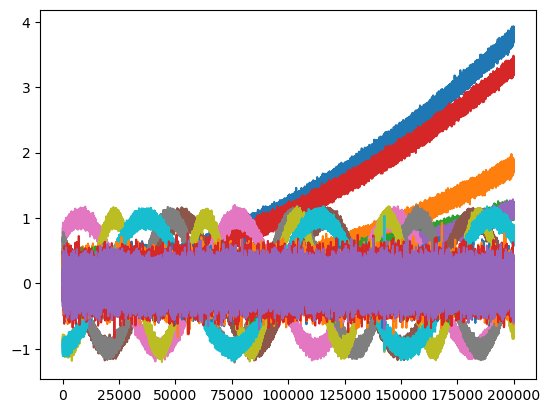

In [34]:
X,y,start = generate_dataset()
print(start)
plt.plot(X)

In [4]:
def plot_mts(X, y): #, regimes):
    T, d = X.shape
    t = np.arange(T)
    
    fig, axes = plt.subplots(5, 1, figsize=(12, 6), sharex=True)
    
    if d == 1:
        axes = [axes]
    
    for j in range(5):
        axes[j].plot(t, X[:, j])
        
        # Highlight anomalies
        anomaly_idx = np.where(y == 1)[0]
        axes[j].scatter(anomaly_idx, X[anomaly_idx, j], s=10)
        
        axes[j].set_ylabel(f"Channel {j}")
    
    
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

In [ ]:
#Use this exact convention from README.md:11:

# [index][DatasetName]id[id][Domain]tr[TrainIndex]1st[FirstAnomalyIndex].csv

# Example:
# 245_MyData_id_1_Sensor_tr_1200_1st_1530.csv

filenames = ['file_name']

for i in range(30):
    X,y,start = generate_dataset()
    filename = f"{i+1}_SyntheticChannels_id_{i}_Sensor_tr_1200_1st_{start}.csv"
    filenames.append(filename)
    df = pd.DataFrame(X, columns=[f"Channel_{j}" for j in range(X.shape[1])])
    df['Label'] = y
    df.to_csv(filename, index=False)


In [17]:
print(y)

[0. 0. 0. ... 0. 0. 0.]


In [15]:
filenames

['filename',
 '1_SyntheticChannels_id_0_Sensor_tr_1200_1st_1411.csv',
 '2_SyntheticChannels_id_1_Sensor_tr_1200_1st_1451.csv',
 '3_SyntheticChannels_id_2_Sensor_tr_1200_1st_1467.csv',
 '4_SyntheticChannels_id_3_Sensor_tr_1200_1st_1422.csv',
 '5_SyntheticChannels_id_4_Sensor_tr_1200_1st_1400.csv',
 '6_SyntheticChannels_id_5_Sensor_tr_1200_1st_1413.csv',
 '7_SyntheticChannels_id_6_Sensor_tr_1200_1st_1421.csv',
 '8_SyntheticChannels_id_7_Sensor_tr_1200_1st_1461.csv',
 '9_SyntheticChannels_id_8_Sensor_tr_1200_1st_1477.csv',
 '10_SyntheticChannels_id_9_Sensor_tr_1200_1st_1439.csv',
 '11_SyntheticChannels_id_10_Sensor_tr_1200_1st_1439.csv',
 '12_SyntheticChannels_id_11_Sensor_tr_1200_1st_1467.csv',
 '13_SyntheticChannels_id_12_Sensor_tr_1200_1st_1479.csv',
 '14_SyntheticChannels_id_13_Sensor_tr_1200_1st_1465.csv',
 '15_SyntheticChannels_id_14_Sensor_tr_1200_1st_1452.csv',
 '16_SyntheticChannels_id_15_Sensor_tr_1200_1st_1412.csv',
 '17_SyntheticChannels_id_16_Sensor_tr_1200_1st_1492.csv',
 '1

In [20]:
import csv
with open('my-data-Eva.csv', 'w', newline='') as file:
    writer = csv.writer(file)

    for name in filenames:
        writer.writerow([name])

In [31]:
def plot_mts(X, y): #, regimes):
    T, d = X.shape
    t = np.arange(T)
    
    fig, axes = plt.subplots(15, 1, figsize=(20, 10), sharex=True)
    
    if d == 1:
        axes = [axes]
    
    for j in range(15):
        axes[j].plot(t, X[:, j])
        
        # Highlight anomalies
        anomaly_idx = np.where(y == 1)[0]
        axes[j].scatter(anomaly_idx, X[anomaly_idx, j], s=10)
        
        axes[j].set_ylabel(f"Channel {j}")
    
    
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

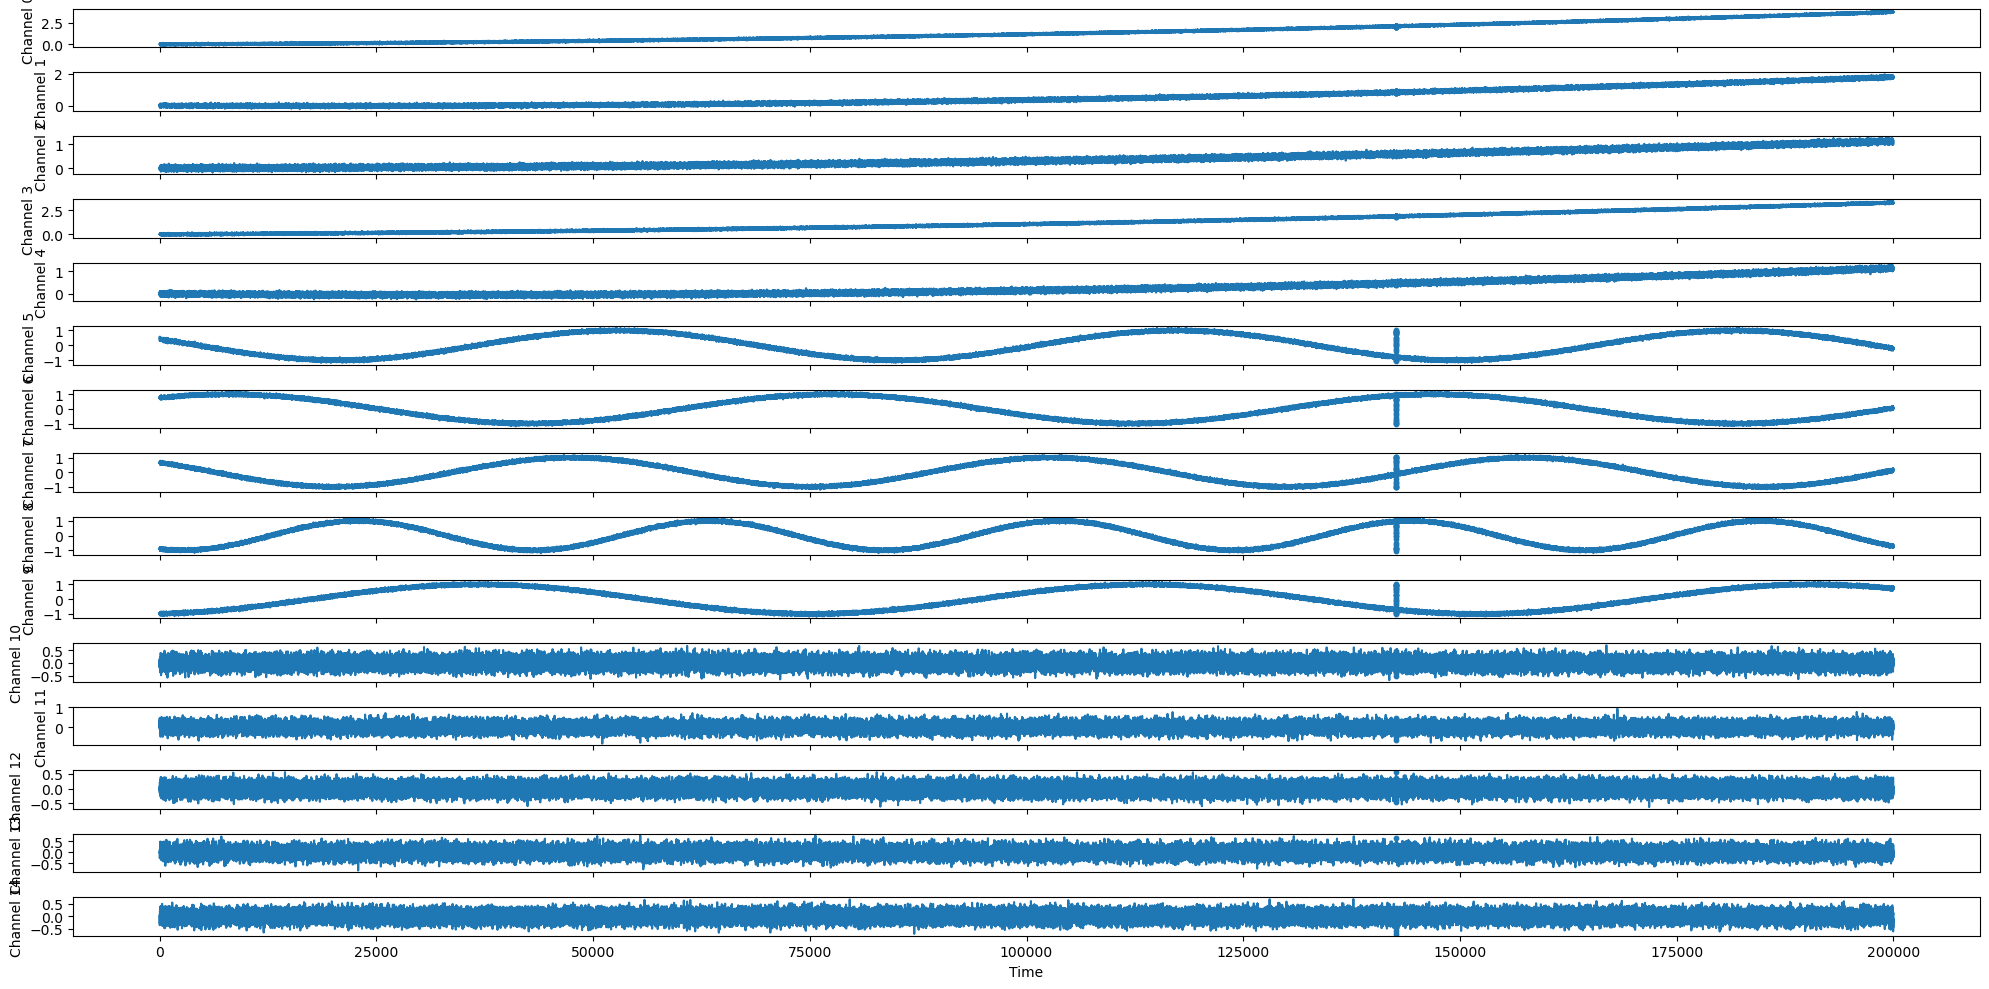

In [35]:
plot_mts(X, y)